训练集形状: (56000, 28, 28)
验证集形状: (14000, 28, 28)
Epoch 1/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.1766 - val_loss: 0.1356
Epoch 2/10
1750/1750 [==============================] - 3s 1ms/step - loss: 0.1265 - val_loss: 0.1194
Epoch 3/10
1750/1750 [==============================] - 3s 1ms/step - loss: 0.1163 - val_loss: 0.1130
Epoch 4/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.1117 - val_loss: 0.1096
Epoch 5/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.1092 - val_loss: 0.1089
Epoch 6/10
1750/1750 [==============================] - 3s 1ms/step - loss: 0.1073 - val_loss: 0.1062
Epoch 7/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.1056 - val_loss: 0.1043
Epoch 8/10
1750/1750 [==============================] - 4s 2ms/step - loss: 0.1036 - val_loss: 0.1021
Epoch 9/10
1750/1750 [==============================] - 5s 3ms/step - loss: 0.1014 - val_loss: 0.1010
Epoch 10/10
438/438 [===============

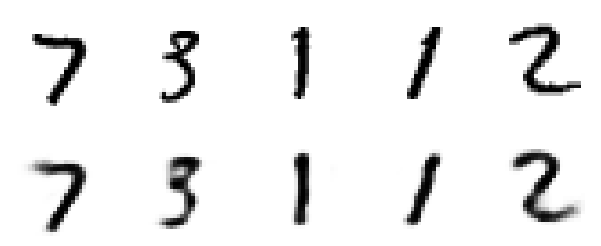

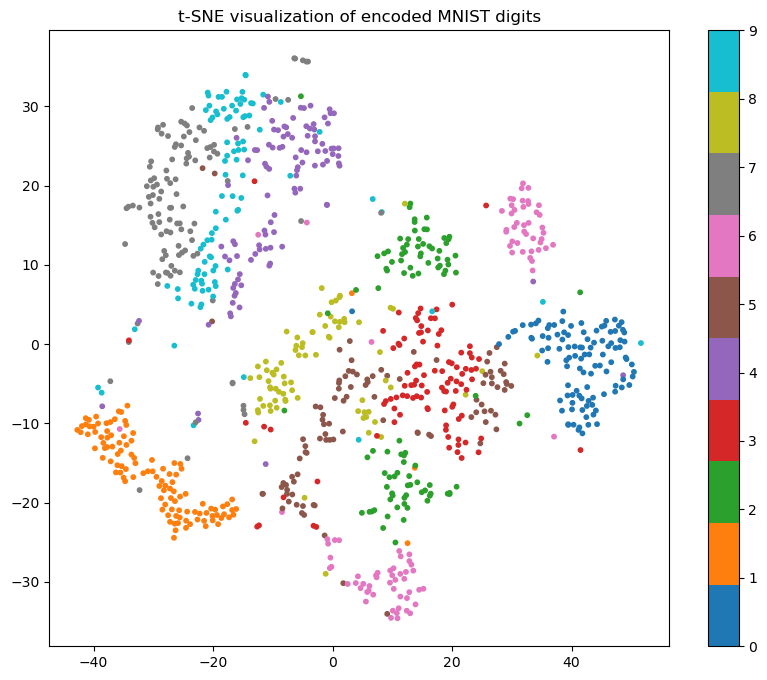

In [11]:
#构建一个简单的线性自动编码器，来对3D数据集执行PCA，将其投影到2D

import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 加载 MNIST 数据集
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data']
y = mnist['target'].astype(np.int32)

# 标准化数据到 [0,1] 范围（因为使用 sigmoid 激活函数）
X = X / 255.0

# 重塑数据为 28x28 图像格式
X = X.reshape(-1, 28, 28)

# 分割训练集和验证集
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 打印数据形状
print(f"训练集形状: {X_train.shape}")
print(f"验证集形状: {X_valid.shape}")

# 堆叠式自动编码器
stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu"),
])

stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])

stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=keras.optimizers.SGD(learning_rate=1.5))  # 注意：lr 已被弃用，使用 learning_rate

history = stacked_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))  # 使用元组而非列表

# 可视化重构
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def show_reconstructions(model, n_images=5):
    reconstructions = model.predict(X_valid[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(X_valid[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

show_reconstructions(stacked_ae)

# 使用 t-SNE 进行可视化
X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_valid_2D = tsne.fit_transform(X_valid_compressed[:1000])  # 使用部分数据加速 t-SNE
y_valid_subset = y_valid[:1000]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid_subset, s=10, cmap="tab10")
plt.colorbar(scatter)
plt.title("t-SNE visualization of encoded MNIST digits")
plt.show()

Epoch 1/10
1750/1750 [==============================] - 4s 2ms/step - loss: 0.6006 - val_loss: 0.4075
Epoch 2/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.3070 - val_loss: 0.2756
Epoch 3/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2714 - val_loss: 0.2687
Epoch 4/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2673 - val_loss: 0.2659
Epoch 5/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2649 - val_loss: 0.2638
Epoch 6/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2630 - val_loss: 0.2619
Epoch 7/10
1750/1750 [==============================] - 3s 1ms/step - loss: 0.2611 - val_loss: 0.2599
Epoch 8/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2591 - val_loss: 0.2578
Epoch 9/10
1750/1750 [==============================] - 3s 2ms/step - loss: 0.2568 - val_loss: 0.2554
Epoch 10/10
438/438 [==============================] - 0s 634us/step


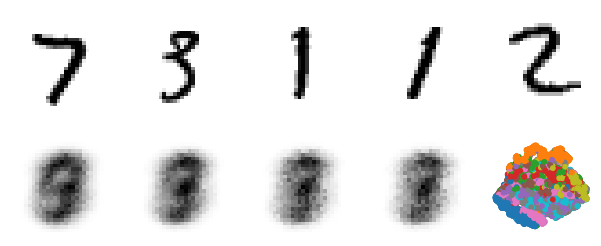

In [12]:
#堆叠式自动编码器

stacked_encoder = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dense(100, activation="selu"), 
    keras.layers.Dense(30, activation="selu"), 
]) 
stacked_decoder = keras.models.Sequential([ 
    keras.layers.Dense(100, activation="selu", input_shape=[30]), 
    keras.layers.Dense(28 * 28, activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder]) 
stacked_ae.compile(loss="binary_crossentropy", 
                   optimizer=keras.optimizers.SGD(lr=1.5)) 
history = stacked_ae.fit(X_train, X_train, epochs=10, 
                         validation_data=[X_valid, X_valid]) 

#可视化重构
def plot_image(image): 
    plt.imshow(image, cmap="binary") 
    plt.axis("off") 
def show_reconstructions(model, n_images=5): 
    reconstructions = model.predict(X_valid[:n_images]) 
    fig = plt.figure(figsize=(n_images * 1.5, 3)) 
    for image_index in range(n_images): 
        plt.subplot(2, n_images, 1 + image_index) 
        plot_image(X_valid[image_index]) 
        plt.subplot(2, n_images, 1 + n_images + image_index) 
        plot_image(reconstructions[image_index]) 
show_reconstructions(stacked_ae)

from sklearn.manifold import TSNE 
X_valid_compressed = stacked_encoder.predict(X_valid) 
tsne = TSNE() 
X_valid_2D = tsne.fit_transform(X_valid_compressed) 
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10") 

In [13]:
#绑定权重

class DenseTranspose(keras.layers.Layer): 
    def __init__(self, dense, activation=None, **kwargs): 
        self.dense = dense 
        self.activation = keras.activations.get(activation) 
        super().__init__( **kwargs) 
    def build(self, batch_input_shape): 
        self.biases = self.add_weight(name="bias", initializer="zeros", 
                                      shape=[self.dense.input_shape[-1]]) 
        super().build(batch_input_shape) 
    def call(self, inputs): 
        z = tf.matmul(inputs, self.dense.weights[0], transpose_b=True) 
        return self.activation(z + self.biases) 

dense_1 = keras.layers.Dense(100, activation="selu") 
dense_2 = keras.layers.Dense(30, activation="selu") 
tied_encoder = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    dense_1, 
    dense_2 
]) 
tied_decoder = keras.models.Sequential([ 
    DenseTranspose(dense_2, activation="selu"), 
    DenseTranspose(dense_1, activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
tied_ae = keras.models.Sequential([tied_encoder, tied_decoder]) 


In [14]:
#卷积自动编码器

conv_encoder = keras.models.Sequential([ 
    keras.layers.Reshape([28, 28, 1], input_shape=[28, 28]), 
    keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="selu"), 
    keras.layers.MaxPool2D(pool_size=2), 
    keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="selu"), 
    keras.layers.MaxPool2D(pool_size=2), 
    keras.layers.Conv2D(64, kernel_size=3, padding="same",activation="selu"), 
    keras.layers.MaxPool2D(pool_size=2) 
]) 
conv_decoder = keras.models.Sequential([ 
    keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="valid", 
                                 activation="selu", 
                                 input_shape=[3, 3, 64]), 
    keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="same", 
                                 activation="selu"), 
    keras.layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding ="same", 
                                 activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
conv_ae = keras.models.Sequential([conv_encoder, conv_decoder]) 

In [15]:
#循环自动编码器

recurrent_encoder = keras.models.Sequential([ 
    keras.layers.LSTM(100, return_sequences=True, input_shape=[None, 28]), 
    keras.layers.LSTM(30) 
]) 
recurrent_decoder = keras.models.Sequential([ 
    keras.layers.RepeatVector(28, input_shape=[30]), 
    keras.layers.LSTM(100, return_sequences=True), 
    keras.layers.TimeDistributed(keras.layers.Dense(28, activation="sigmoid")) 
]) 
recurrent_ae = keras.models.Sequential([recurrent_encoder, recurrent_decoder]) 

In [19]:
#去噪自动编码器
dropout_encoder = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(100, activation="selu"), 
    keras.layers.Dense(30, activation="selu") 
]) 
dropout_decoder = keras.models.Sequential([ 
    keras.layers.Dense(100, activation="selu", input_shape=[30]), 
    keras.layers.Dense(28 * 28, activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
dropout_ae = keras.models.Sequential([dropout_encoder, dropout_decoder]) 

In [17]:
#稀疏自动编码器

sparse_l1_encoder = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dense(100, activation="selu"), 
    keras.layers.Dense(300, activation="sigmoid"), 
    keras.layers.ActivityRegularization(l1=1e-3) 
]) 
sparse_l1_decoder = keras.models.Sequential([ 
    keras.layers.Dense(100, activation="selu", input_shape=[300]), 
    keras.layers.Dense(28 * 28, activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
sparse_l1_ae = keras.models.Sequential([sparse_l1_encoder, sparse_l1_decoder]) 

Kullback–Leibler散度:

$$
D_{\mathrm{KL}}(P \parallel Q) = \sum_i P(i) \log \frac{P(i)}{Q(i)}
$$

目标稀疏度 $p$ 与实际稀疏度 $q$ 之间的KL散度:

$$
D_{\mathrm{KL}}(p \parallel q) = p \log \frac{p}{q} + (1 - p) \log \frac{1 - p}{1 - q}
$$

一旦我们计算了编码层中每个神经元的稀疏损失，就把这些损失相
加并将结果加到成本函数中。为了控制稀疏损失和重建损失的相对重要
性，我们可以将稀疏损失乘以稀疏权重超参数。如果此权重过高，则模
型会接近目标稀疏度，但可能无法正确重构输入，从而使模型没什么用
处。相反，如果它太低，则该模型会忽略稀疏性目标，不会学习任何有
趣的特征。

In [20]:
K = keras.backend 
kl_divergence = keras.losses.kullback_leibler_divergence 
class KLDivergenceRegularizer(keras.regularizers.Regularizer): 
    def __init__(self, weight, target=0.1): 
        self.weight = weight 
        self.target = target 
    def __call__(self, inputs): 
        mean_activities = K.mean(inputs, axis=0) 
        return self.weight * ( 
            kl_divergence(self.target, mean_activities) + 
            kl_divergence(1. - self.target, 1. - mean_activities)) 
kld_reg = KLDivergenceRegularizer(weight=0.05, target=0.1) 
sparse_kl_encoder = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dense(100, activation="selu"), 
    keras.layers.Dense(300, activation="sigmoid", activity_regularizer=kld_reg) 
]) 
sparse_kl_decoder = keras.models.Sequential([ 
    keras.layers.Dense(100, activation="selu", input_shape=[300]), 
    keras.layers.Dense(28 * 28, activation="sigmoid"), 
    keras.layers.Reshape([28, 28]) 
]) 
sparse_kl_ae = keras.models.Sequential([sparse_kl_encoder, sparse_kl_decoder])

变分自编码器的潜在损失:

$$
\mathcal{L} = -\frac{1}{2} \sum_{i=1}^{K} \left( 1 + \log(\sigma_i^2) - \sigma_i^2 - \mu_i^2 \right)
$$

在这个等式中：
- $\mathcal{L}$ 是潜在损失（latent loss），
- $K$ 是编码的维度，
- $\mu_i$ 和 $\sigma_i$ 是编码器输出的第 $i$ 个分量的均值和标准差；
- 向量 $\boldsymbol{\mu}$ 和 $\boldsymbol{\sigma}$（包含所有 $\mu_i$ 和 $\sigma_i$）由编码器输出。

---

变分自动编码器架构的常见调整是使编码器输出 $\gamma_i = \log(\sigma_i^2)$ 而不是 $\sigma_i$。然后可以如公式17-4所示计算潜在损失。这种方法在数值上更稳定，而且可以加快训练速度。

变分自编码器的潜在损失，用 $\gamma = \log(\sigma^2)$ 重写:

$$
\mathcal{L} = -\frac{1}{2} \sum_{i=1}^{K} \left( 1 + \gamma_i - \exp(\gamma_i) - \mu_i^2 \right)
$$

In [21]:
class Sampling(keras.layers.Layer): 
    def call(self, inputs): 
        mean, log_var = inputs 
        return K.random_normal(tf.shape(log_var)) * K.exp(log_var / 2) + mean

codings_size = 10 
inputs = keras.layers.Input(shape=[28, 28]) 
z = keras.layers.Flatten()(inputs) 
z = keras.layers.Dense(150, activation="selu")(z) 
z = keras.layers.Dense(100, activation="selu")(z) 
codings_mean = keras.layers.Dense(codings_size)(z) # μ 
codings_log_var = keras.layers.Dense(codings_size)(z) # γ 
codings = Sampling()([codings_mean, codings_log_var]) 
variational_encoder = keras.Model( 
    inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])
decoder_inputs = keras.layers.Input(shape=[codings_size]) 
x = keras.layers.Dense(100, activation="selu")(decoder_inputs) 
x = keras.layers.Dense(150, activation="selu")(x) 
x = keras.layers.Dense(28 * 28, activation="sigmoid")(x) 
outputs = keras.layers.Reshape([28, 28])(x) 
variational_decoder = keras.Model(inputs=[decoder_inputs], outputs= [outputs])

_, _, codings = variational_encoder(inputs) 
reconstructions = variational_decoder(codings) 
variational_ae = keras.Model(inputs=[inputs], outputs=[reconstructions]) 
latent_loss = -0.5 * K.sum( 
    1 + codings_log_var - K.exp(codings_log_var) - K.square(codings_mean), 
    axis=-1) 
variational_ae.add_loss(K.mean(latent_loss) / 784.) 
variational_ae.compile(loss="binary_crossentropy", optimizer="rmsprop") 
history = variational_ae.fit(X_train, X_train, epochs=50, batch_size=128, 
                           validation_data=[X_valid, X_valid]) 

Epoch 1/50
438/438 [==============================] - 3s 6ms/step - loss: 0.2555 - val_loss: 0.2156
Epoch 2/50
438/438 [==============================] - 2s 4ms/step - loss: 0.2029 - val_loss: 0.1917
Epoch 3/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1874 - val_loss: 0.1821
Epoch 4/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1804 - val_loss: 0.1773
Epoch 5/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1758 - val_loss: 0.1723
Epoch 6/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1718 - val_loss: 0.1692
Epoch 7/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1684 - val_loss: 0.1668
Epoch 8/50
438/438 [==============================] - 2s 4ms/step - loss: 0.1655 - val_loss: 0.1629
Epoch 9/50
438/438 [==============================] - 2s 5ms/step - loss: 0.1631 - val_loss: 0.1633
Epoch 10/50
438/438 [==============================] - 2s 5ms/step - loss: 0.1612 - val_loss: 0.1605

In [22]:
codings = tf.random.normal(shape=[12, codings_size]) 
images = variational_decoder(codings).numpy() 

In [23]:
codings_grid = tf.reshape(codings, [1, 3, 4, codings_size]) 
larger_grid = tf.image.resize(codings_grid, size=[5, 7]) 
interpolated_codings = tf.reshape(larger_grid, [-1, codings_size]) 
images = variational_decoder(interpolated_codings).numpy()